In [1]:
from __future__ import print_function
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , normalize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC

import warnings
warnings.filterwarnings('ignore')

In [2]:
url= "creditcard.csv"
data=pd.read_csv(url)
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


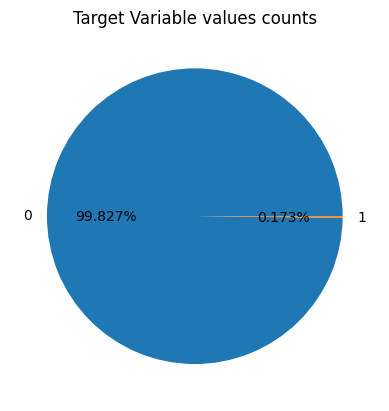

In [3]:
labels = data.Class.unique()

sizes = data.Class.value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels= labels, autopct='%1.3f%%')
ax.set_title('Target Variable values counts')
plt.show()

<Axes: >

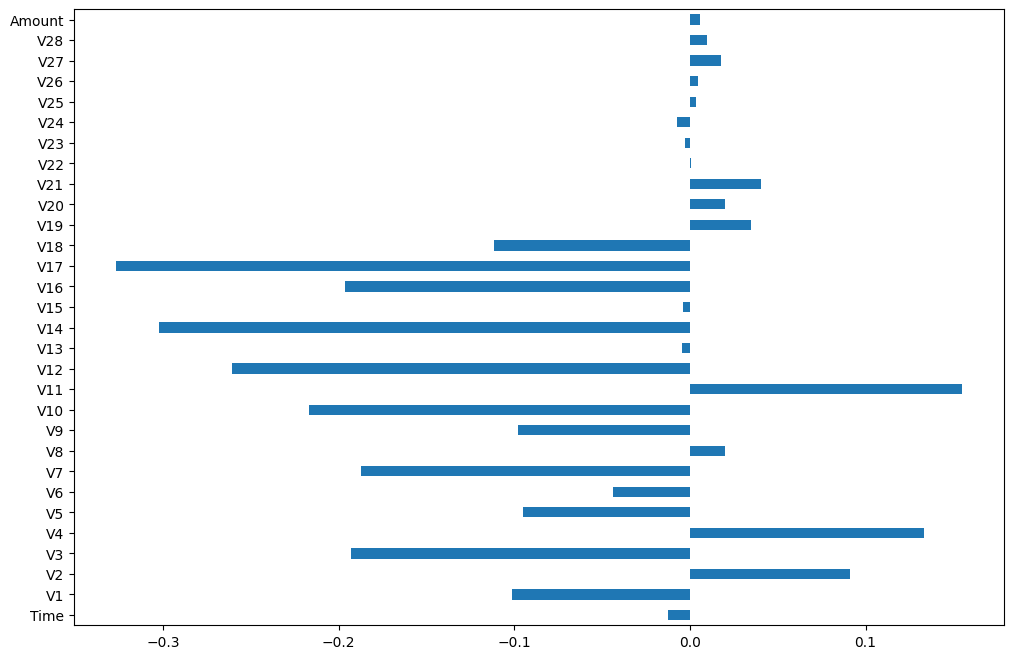

In [4]:
correlation_values = data.corr()['Class'].drop('Class')
correlation_values.plot(kind='barh', figsize=(12,8))

# Dataset Preprocessing

In [5]:
# standardize features by removing the mean and scaling to unit variance
data.iloc[: ,1:30] = StandardScaler().fit_transform(data.iloc[: ,1:30])
data_matrix = data.values

# X: feature matrix (for this analysis, we exclude the Time variable from the dataset)
x = data_matrix[:, 1:30]

# y: labels vector
y = data_matrix[:, :30]

# data normalization
x = normalize(x , norm='l1')

# Dataset Train/Test Split

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Build a Decision Tree Classifier model 

In [7]:
w_train = compute_sample_weight('balanced', y_train)

# for reproducible output across multiple function calls, set random_state to a given integer value
dt = DecisionTreeClassifier(max_depth=4, random_state=35)
y_train = np.argmax(y_train, axis=1)
dt.fit(x_train, y_train, sample_weight=w_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,35
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None



# Build a Support Vector Machine model 

In [ ]:
svm = LinearSVC(class_weight='balanced', random_state=31, loss='hinge', fit_intercept=False)
svm.fit(x_train, y_train)

# Evaluate the Decision Tree Classifier Models

In [ ]:
print(y_test.shape)
print(np.unique(y_test))

In [ ]:
# 1. Ensure y_test is class labels, not one-hot
y_test_labels = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test.squeeze()

# 2. Ensure predicted probabilities are for class 1
y_pred_dt = dt.predict_proba(x_test)[:, 1]

# 3. Compute ROC-AUC
roc_auc_dt = roc_auc_score(y_test_labels, y_pred_dt)
print('Decision Tree ROC-AUC score : {0:.3f}'.format(roc_auc_dt))


# Evaluate the Support Vector Machine Models

In [ ]:

from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Train SVM
svm = SVC(probability=True)
svm.fit(x_train, y_train)

# 2. Predict class probabilities
y_scores = svm.predict_proba(x_test)

# 3. Ensure y_test is label format
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# 4. Get only present classes in y_true
present_classes = np.unique(y_true)

# 5. Filter score columns for only present classes
col_indices = [i for i, cls in enumerate(svm.classes_) if cls in present_classes]
y_scores_filtered = y_scores[:, col_indices]

# 6. Compute ROC-AUC safely
auc = roc_auc_score(y_true, y_scores_filtered, multi_class='ovr', average='macro', labels=present_classes)
print("SVM ROC-AUC score: {:.3f}".format(auc))

#### Q1. Currently, we have used all 30 features of the dataset for training the models. Use the `corr()` function to find the top 6 features of the dataset to train the models on. 


In [ ]:
correlation_values = abs(data.corr()['Class']).drop('Class')
correlation_values = correlation_values.sort_values(ascending=False)[:6]
correlation_values

#### Q2. Using only these 6 features, modify the input variable for training.


In [ ]:
x  = data_matrix[:,[3,10,12,14,16,17]]
y = data_matrix[:, :30]
x = normalize(x , norm='l1')
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
w_train = compute_sample_weight('balanced', y_train)

dt = DecisionTreeClassifier(max_depth=4, random_state=35)
y_train = np.argmax(y_train, axis=1)
dt.fit(x_train, y_train, sample_weight=w_train)
svm = LinearSVC(class_weight='balanced', random_state=31, loss='hinge', fit_intercept=False)
svm.fit(x_train, y_train)
y_test_labels = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test.squeeze()

y_pred_dt = dt.predict_proba(x_test)[:, 1]
roc_auc_dt = roc_auc_score(y_test_labels, y_pred_dt)
print('Decision Tree ROC-AUC score : {0:.3f}'.format(roc_auc_dt))

In [ ]:
svm = SVC(probability=True)
svm.fit(x_train, y_train)

# 2. Predict class probabilities
y_scores = svm.predict_proba(x_test)

# 3. Ensure y_test is label format
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# 4. Get only present classes in y_true
present_classes = np.unique(y_true)

# 5. Filter score columns for only present classes
col_indices = [i for i, cls in enumerate(svm.classes_) if cls in present_classes]
y_scores_filtered = y_scores[:, col_indices]

# 6. Compute ROC-AUC safely
auc = roc_auc_score(y_true, y_scores_filtered, multi_class='ovr', average='macro', labels=present_classes)
print("SVM ROC-AUC score: {:.3f}".format(auc))